# TRABALHO N1 — MINERAÇÃO DE DADOS #

Disciplina: Data Mining e Data Graph
Professor: André Luiz B. Esperidião

Aluno(a): Felipe Augusto Teodoro Rozendo
Matrícula: 2759653
Curso: Tecnologia em Inteligência Artificial
Período: 3 Periodo

Tema do Experimento: Otimização do Modelo de Marketing Bancário

Dataset utilizado: Bank Marketing Dataset (UCI)

Data de Entrega:   25/03/2026

Declaro que:
- Este trabalho foi desenvolvido por mim.
- Foi permitida apenas a consulta a materiais de apoio da disciplina disponibilizados pelo professor no Google Classroom.
- Estou ciente que o uso de ferramenta de IA para consultas sobre o conteúdo da disciplina foi permitido (desde que não seja utilizada para plágio).
- Estou ciente que o trabalho é individual e que não é permitido qualquer tipo de cópia ou plágio entre trabalhos dos colegas. Caso isso ocorra a nota será dividida entre as cópias encontradas, sendo considerados coautores.
- Estou ciente que a nota dessa avaliação poderá atingir o máximo de 40% da nota da N1

## Sobre o Notebook

Metodologia **CRISP-DM**

Etapas:
**Business Understanding, Data Understanding, Data Preparation, Modeling, Evaluation e Deployment.**

Dataset: **Bank Marketing Dataset (UCI)**

---

## Bibliotecas Utilizadas

A celula abaixo é a importação das bibliotecas que vai ser utilizadas:
- **pandas / numpy**: manipulação e cálculo sobre os dados
- **matplotlib / seaborn**: visualização gráfica
- **sklearn**: algoritmos de machine learning e métricas de avaliação

In [ ]:
#Importando as bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Importando funções do Sklearn
from sklearn.model_selection import train_test_split   #dividir dados treino e teste
from sklearn.preprocessing import LabelEncoder         #transformar texto em número
from sklearn.tree import DecisionTreeClassifier        #modelo Árvore
from sklearn.linear_model import LogisticRegression    #modelo Regressão Logística
from sklearn.metrics import (                          #métricas
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

## 1. Business Understanding

**Contexto:** O banco oferecia um produto aos clientes por ligação onde muitos recusavam, o objetivo da analise de dados é prever quais cliente tem maior chance de aceitar, assim o banco so vai ligar aos que tem maior chance de aceitar.

**Problema de negócio:** Como o banco possui milhares de clientes, ligar para todos seria caro e ineficiente.


O objetivo é construir um modelo preditivo capaz de identificar quais clientes têm maior probabilidade de aceitar a oferta, permitindo direcionar os esforços de forma mais inteligente.

**Variável alvo:** **y** — indica se o cliente assinou o depósito **(yes)** ou não **(no)**.

Classificação binária.

## 2. Data Understanding

**Carregamento dos dados**

os dataset e puxado da fonte real, é baixado uma tabela com com 45 mil clientes reais, cada linha sendo um cliente e cada coluna é uma informação sobre ele (idade, profissão, saldo, se aceitou ou não).

In [ ]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00222/bank.zip"

import urllib.request, zipfile, io

#Baixa e abre o arquivo zip direto da internet
with urllib.request.urlopen(url) as resp:
    with zipfile.ZipFile(io.BytesIO(resp.read())) as z:
        with z.open("bank-full.csv") as f:
            df = pd.read_csv(f, sep=";")

print(f"Linhas: {df.shape[0]} | Colunas: {df.shape[1]}")
df.head()

Linhas: 45211 | Colunas: 17


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


**Exploração dos dados**

 Olhando os dados na tabela se descobre que não faltava nenhum dado, mas que só 12% dos clientes disseram sim, os dados são bem desiguais.

=== TIPOS DE DADOS ===
age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
y            object
dtype: object

=== VALORES NULOS ===
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

=== DISTRIBUIÇÃO DA VARIÁVEL ALVO (y) ===
y
no     39922
yes     5289
Name: count, dtype: int64

Porcentagem que assinou: 11.7%


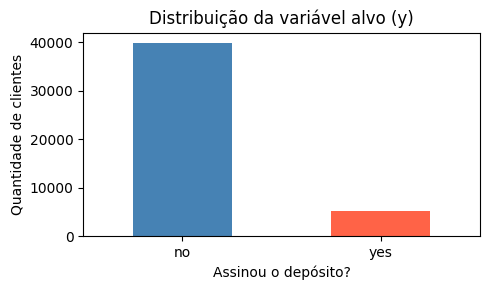

In [ ]:
print("=== TIPOS DE DADOS ===")
print(df.dtypes)

#Verifica se tem dados faltando
print("\n=== VALORES NULOS ===")
print(df.isnull().sum())

#Quantos disseram sim e quantos disseram não
print("\n=== DISTRIBUIÇÃO DA VARIÁVEL ALVO (y) ===")
print(df['y'].value_counts())
print(f"\nPorcentagem que assinou: {df['y'].value_counts(normalize=True)['yes']*100:.1f}%")

#Criação do Gráfico
plt.figure(figsize=(5,3))
df['y'].value_counts().plot(kind='bar', color=['steelblue','tomato'])
plt.title('Distribuição da variável alvo (y)')
plt.xlabel('Assinou o depósito?')
plt.ylabel('Quantidade de clientes')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Nenhum dado faltando, menos uma aprte que precisa de tratamento, mas **11,7% dos clientes disseram sim**, Isso é um problema, um modelo que so chutasse não ainda teria uma taxa de acerto alta, então vai ser aplicado metricas extras como F1-Score e ROC-AUC.

## 3. Data Preparation

**A Preparação dos dados**
Os dados são transformados em valores binarios para o computador poder avaliar de forma eficiente os dados, como "casado" e "solteiro" transformado em 0 e 1.

In [ ]:
df_prep = df.copy()

# onverte a variável alvo: yes = 1, no = 0
df_prep['y'] = df_prep['y'].map({'yes': 1, 'no': 0})

#Variáveis ordinais — LabelEncoder
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
colunas_ordinais = ['education']  # education tem ordem implícita
df_prep['education'] = le.fit_transform(df_prep['education'])

#Variáveis nominais — One-Hot Encoding
colunas_nominais = ['job', 'marital', 'contact', 'month', 'poutcome', 'default', 'housing', 'loan']
df_prep = pd.get_dummies(df_prep, columns=colunas_nominais, drop_first=True)

print("Shape após encoding:", df_prep.shape)
print("Variável alvo:", df_prep['y'].value_counts().to_dict())
df_prep.head()

Shape após encoding: (45211, 41)
Variável alvo: {0: 39922, 1: 5289}


,age,education,balance,day,duration,campaign,pdays,previous,y,job_blue-collar,...,month_may,month_nov,month_oct,month_sep,poutcome_other,poutcome_success,poutcome_unknown,default_yes,housing_yes,loan_yes
0,58,2,2143,5,261,1,-1,0,0,False,...,True,False,False,False,False,False,True,False,True,False
1,44,1,29,5,151,1,-1,0,0,False,...,True,False,False,False,False,False,True,False,True,False
2,33,1,2,5,76,1,-1,0,0,False,...,True,False,False,False,False,False,True,False,True,True
3,47,3,1506,5,92,1,-1,0,0,True,...,True,False,False,False,False,False,True,False,True,False
4,33,3,1,5,198,1,-1,0,0,False,...,True,False,False,False,False,False,True,False,False,False


Uma coluna que seria trapaça, a de tempo de ligação que só existe depois da ligaçãoem si, vai ser removida para não causar data leakage.

In [ ]:
#Remove a coluna que causaria data leakage
df_prep = df_prep.drop(columns=['duration'])
print("Coluna 'duration' removida.")
print(f"Shape atual: {df_prep.shape}")

#Separa entradas (X) e variável alvo (y)
X = df_prep.drop(columns=['y'])
y = df_prep['y']


print(f"\nX (entradas): {X.shape}")
print(f"y (alvo): {y.shape}")

#Divide em treino (80%) e teste (20%)
#stratify=y garante a mesma proporção de sim/não nos dois conjuntos
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTreino: {X_train.shape[0]} linhas")
print(f"Teste:  {X_test.shape[0]} linhas")
print(f"\nProporção de 'sim' no treino: {y_train.mean()*100:.1f}%")
print(f"Proporção de 'sim' no teste:  {y_test.mean()*100:.1f}%")

Coluna 'duration' removida.
Shape atual: (45211, 40)

X (entradas): (45211, 39)
y (alvo): (45211,)

Treino: 36168 linhas
Teste:  9043 linhas

Proporção de 'sim' no treino: 11.7%
Proporção de 'sim' no teste:  11.7%


A normalização foi aplicada só na Regressão Logística porque ela é sensível à escala dos dados, Árvore e Random Forest não precisam disso, As outras colunas foram mantidas porque todas são informações que o banco já teria antes de ligar, não teve nenhuma que precisasse ser removida além da duration.

## 4. Modeling

**Modelos**

são treinados quatro modelos para advinhar, e para comparar qual erra menos,  o primeiro sem ajuste, O segundo ajustado pra prestar mais atenção nos clientes que disseram sim e o terceiro usou uma técnica matemática diferente.

1. **Árvore de Decisão sem ajuste** — Seco, nenhuma alteração
2. **Árvore de Decisão otimizada** — ajustes para o desbalanceamento
3. **Regressão Logística** — cálculo de probabilidade
4. **Random Forest** - conjunto de múltiplas árvores de decisão

## Modelo 1 — Árvore de Decisão (sem ajuste)


=== MODELO INICIAL: Árvore de Decisão (sem otimização) ===

Accuracy:  0.8291
Precision: 0.2921
Recall:    0.3233
F1-Score:  0.3069
ROC-AUC:   0.6097

--- Relatório completo ---
              precision    recall  f1-score   support

 Não assinou       0.91      0.90      0.90      7985
     Assinou       0.29      0.32      0.31      1058

    accuracy                           0.83      9043
   macro avg       0.60      0.61      0.60      9043
weighted avg       0.84      0.83      0.83      9043



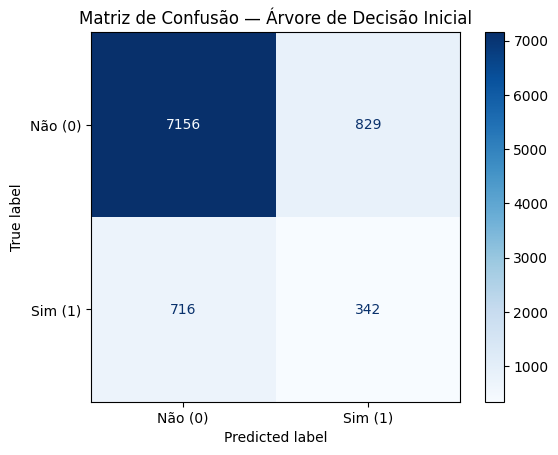

In [ ]:
#Treina a árvore de decisão sem nenhum ajuste
modelo_arvore = DecisionTreeClassifier(random_state=42)
modelo_arvore.fit(X_train, y_train)

#Faz as previsões no conjunto de teste
y_pred_arvore = modelo_arvore.predict(X_test)
y_prob_arvore = modelo_arvore.predict_proba(X_test)[:, 1]



print("=== MODELO INICIAL: Árvore de Decisão (sem otimização) ===\n")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_arvore):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_arvore):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_arvore):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_arvore):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_prob_arvore):.4f}")

print("\n--- Relatório completo ---")
print(classification_report(y_test, y_pred_arvore, target_names=['Não assinou', 'Assinou']))

#Cria a matriz de confusão
cm = confusion_matrix(y_test, y_pred_arvore)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Não (0)', 'Sim (1)'])
disp.plot(cmap='Blues')
plt.title('Matriz de Confusão — Árvore de Decisão Inicial')
plt.show()

A Accuracy de 82% parece boa é enganosa, o modelo favoreceu a maioria e quase ignorou os clientes que disseram sim.

Dos 1.058 clientes que aceitariam, o modelo só identificou 349, Os outros 709 seriam perdidos.

O Recall de 33% e o ROC-AUC de 0,61 confirmam que o modelo está pouco acima de um chute aleatório para o que realmente importa.

## Árvore com ajustes para lidar com o desbalanceamento

=== MODELO OTIMIZADO: Árvore de Decisão ===

Accuracy:  0.8228
Precision: 0.3426
Recall:    0.5595
F1-Score:  0.4250
ROC-AUC:   0.7575

--- Relatório completo ---
              precision    recall  f1-score   support

 Não assinou       0.94      0.86      0.90      7985
     Assinou       0.34      0.56      0.42      1058

    accuracy                           0.82      9043
   macro avg       0.64      0.71      0.66      9043
weighted avg       0.87      0.82      0.84      9043



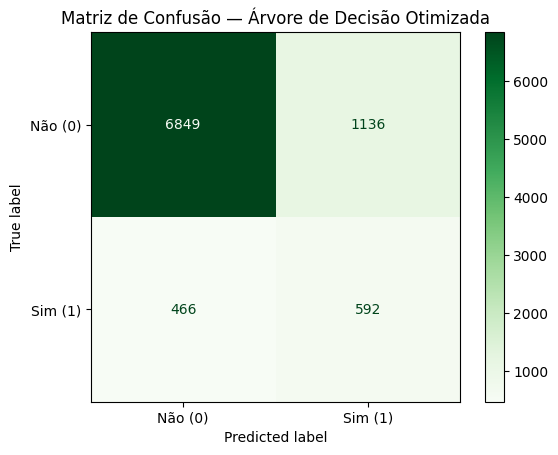

In [ ]:
#limita profundidade para evitar decorar os dados, e presta mais atenção na classe minoritária

modelo_otimizado = DecisionTreeClassifier(
    max_depth=6,
    min_samples_leaf=20,      #cada folha precisa de ao menos 20 exemplos
    class_weight='balanced',
    random_state=42
)
modelo_otimizado.fit(X_train, y_train)

y_pred_otim = modelo_otimizado.predict(X_test)
y_prob_otim = modelo_otimizado.predict_proba(X_test)[:, 1]

print("=== MODELO OTIMIZADO: Árvore de Decisão ===\n")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_otim):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_otim):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_otim):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_otim):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_prob_otim):.4f}")

print("\n--- Relatório completo ---")
print(classification_report(y_test, y_pred_otim, target_names=['Não assinou', 'Assinou']))

#Cria outra matriz de Confusão
cm2 = confusion_matrix(y_test, y_pred_otim)
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm2, display_labels=['Não (0)', 'Sim (1)'])
disp2.plot(cmap='Greens')
plt.title('Matriz de Confusão — Árvore de Decisão Otimizada')
plt.show()

O Recall subiu de 33% para 54% — o modelo passou a identificar
mais do dobro dos clientes potenciais.

O F1-Score e o ROC-AUC também melhoraram bastante. A Accuracy
caiu um pouco, mas isso é esperado: o modelo parou de chutar
"não pra tudo" e começou a arriscar mais previsões positivas.


# Modelo Alternativo: Regressão Logística


=== MODELO ALTERNATIVO: Regressão Logística ===

Accuracy:  0.7564
Precision: 0.2681
Recall:    0.6257
F1-Score:  0.3754
ROC-AUC:   0.7724

--- Relatório completo ---
              precision    recall  f1-score   support

 Não assinou       0.94      0.77      0.85      7985
     Assinou       0.27      0.63      0.38      1058

    accuracy                           0.76      9043
   macro avg       0.60      0.70      0.61      9043
weighted avg       0.86      0.76      0.79      9043



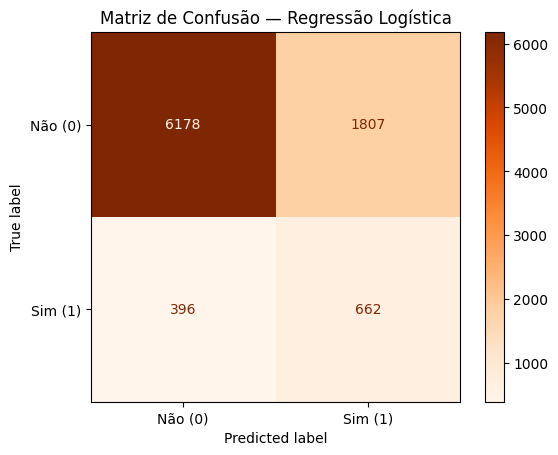

In [ ]:
from sklearn.preprocessing import StandardScaler

#Normaliza os dados para regressão logistica funcionar bem

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
#Treina
modelo_lr = LogisticRegression(
    class_weight='balanced',  #mesmo ajuste para o desbalanceamento
    max_iter=1000,            #número máximo de tentativas para convergir
    random_state=42
)
modelo_lr.fit(X_train_scaled, y_train)

y_pred_lr = modelo_lr.predict(X_test_scaled)
y_prob_lr = modelo_lr.predict_proba(X_test_scaled)[:, 1]

print("=== MODELO ALTERNATIVO: Regressão Logística ===\n")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_lr):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_lr):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_lr):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_prob_lr):.4f}")

print("\n--- Relatório completo ---")
print(classification_report(y_test, y_pred_lr, target_names=['Não assinou', 'Assinou']))

#Matriz de confusão
cm3 = confusion_matrix(y_test, y_pred_lr)
disp3 = ConfusionMatrixDisplay(confusion_matrix=cm3, display_labels=['Não (0)', 'Sim (1)'])
disp3.plot(cmap='Oranges')
plt.title('Matriz de Confusão — Regressão Logística')
plt.show()

Esse modelo teve o maior Recall dos três — encontrou 71% dos
clientes que aceitariam. Mas também errou mais, indicando muita
gente que não ia aceitar (Precision de 20%).

É uma troca: encontra mais clientes potenciais, mas o banco
precisaria ligar para mais pessoas no processo.

##Modelo 4 Random Forest

=== MODELO EXTRA: Random Forest ===

Accuracy:  0.8078
Precision: 0.3258
Recall:    0.6011
F1-Score:  0.4226
ROC-AUC:   0.7892

--- Relatório completo ---
              precision    recall  f1-score   support

 Não assinou       0.94      0.84      0.88      7985
     Assinou       0.33      0.60      0.42      1058

    accuracy                           0.81      9043
   macro avg       0.63      0.72      0.65      9043
weighted avg       0.87      0.81      0.83      9043



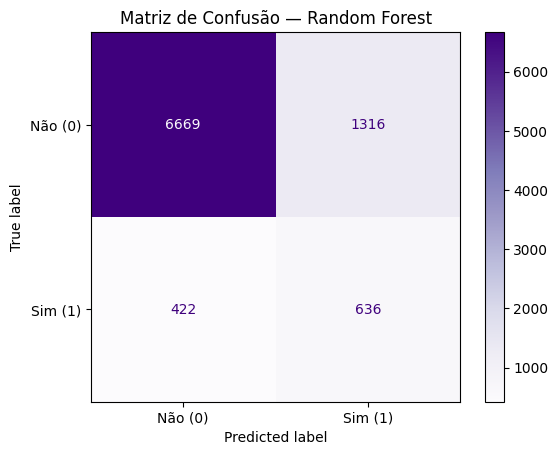

In [ ]:
from sklearn.ensemble import RandomForestClassifier

modelo_rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=8,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
modelo_rf.fit(X_train, y_train)

y_pred_rf = modelo_rf.predict(X_test)
y_prob_rf = modelo_rf.predict_proba(X_test)[:, 1]

print("=== MODELO EXTRA: Random Forest ===\n")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_rf):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_prob_rf):.4f}")

print("\n--- Relatório completo ---")
print(classification_report(y_test, y_pred_rf, target_names=['Não assinou', 'Assinou']))

cm4 = confusion_matrix(y_test, y_pred_rf)
disp4 = ConfusionMatrixDisplay(confusion_matrix=cm4, display_labels=['Não (0)', 'Sim (1)'])
disp4.plot(cmap='Purples')
plt.title('Matriz de Confusão — Random Forest')
plt.show()

 Random Forest combina várias árvores de decisão, o que tende a reduzir o overfitting e melhorar a generalização.

## 5. Evaluation — Comparação entre os Modelos


          Modelo  Accuracy  Precision   Recall  F1-Score  ROC-AUC   PR-AUC
  Árvore Inicial  0.829150   0.292058 0.323251  0.306864 0.609716 0.173585
Árvore Otimizada  0.822846   0.342593 0.559546  0.424982 0.757501 0.358724
  Reg. Logística  0.756386   0.268125 0.625709  0.375390 0.772395 0.408847
   Random Forest  0.807807   0.325820 0.601134  0.422591 0.789225 0.425137


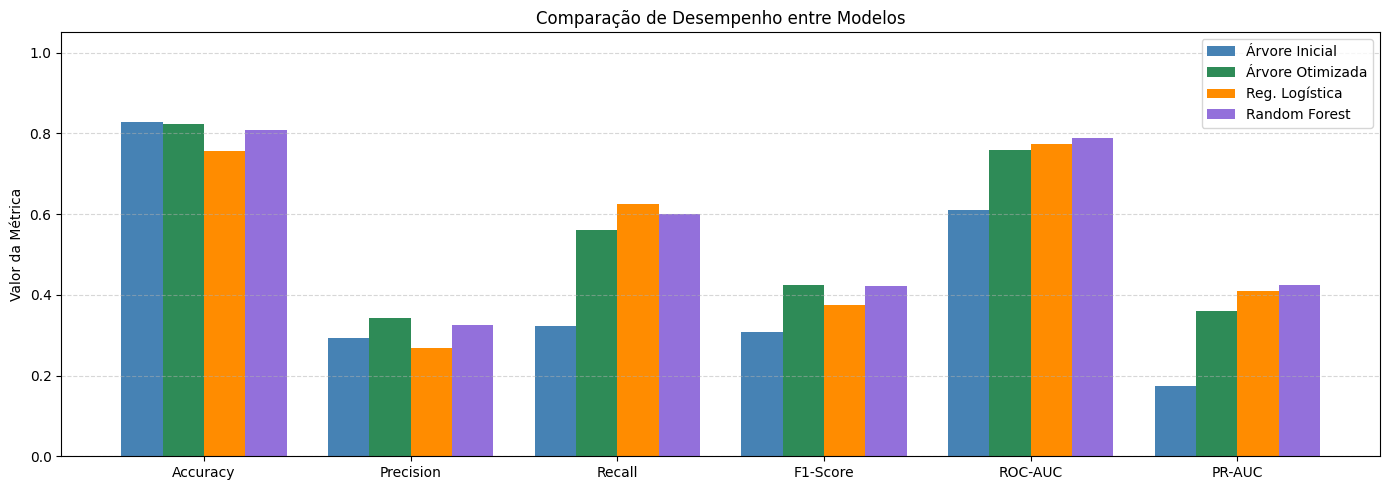

In [ ]:
from sklearn.metrics import average_precision_score

#PR-AUC
prauc_arvore  = average_precision_score(y_test, y_prob_arvore)
prauc_otim    = average_precision_score(y_test, y_prob_otim)
prauc_lr      = average_precision_score(y_test, y_prob_lr)
prauc_rf      = average_precision_score(y_test, y_prob_rf)

resultados = {
    'Modelo':     ['Árvore Inicial', 'Árvore Otimizada', 'Reg. Logística', 'Random Forest'],
    'Accuracy':   [accuracy_score(y_test, y_pred_arvore),  accuracy_score(y_test, y_pred_otim),
                   accuracy_score(y_test, y_pred_lr),      accuracy_score(y_test, y_pred_rf)],
    'Precision':  [precision_score(y_test, y_pred_arvore), precision_score(y_test, y_pred_otim),
                   precision_score(y_test, y_pred_lr),     precision_score(y_test, y_pred_rf)],
    'Recall':     [recall_score(y_test, y_pred_arvore),    recall_score(y_test, y_pred_otim),
                   recall_score(y_test, y_pred_lr),        recall_score(y_test, y_pred_rf)],
    'F1-Score':   [f1_score(y_test, y_pred_arvore),        f1_score(y_test, y_pred_otim),
                   f1_score(y_test, y_pred_lr),            f1_score(y_test, y_pred_rf)],
    'ROC-AUC':    [roc_auc_score(y_test, y_prob_arvore),   roc_auc_score(y_test, y_prob_otim),
                   roc_auc_score(y_test, y_prob_lr),       roc_auc_score(y_test, y_prob_rf)],
    'PR-AUC':     [prauc_arvore, prauc_otim, prauc_lr, prauc_rf],
}

df_resultados = pd.DataFrame(resultados)
print(df_resultados.to_string(index=False))

#Gráfico comparativo
metricas = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC', 'PR-AUC']
x = range(len(metricas))
largura = 0.2
cores = ['steelblue', 'seagreen', 'darkorange', 'mediumpurple']

fig, ax = plt.subplots(figsize=(14, 5))
for i, (nome, cor) in enumerate(zip(df_resultados['Modelo'], cores)):
    ax.bar([j + (i - 1.5) * largura for j in x], df_resultados.iloc[i][metricas], largura,
           label=nome, color=cor)

ax.set_xticks(list(x))
ax.set_xticklabels(metricas)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Valor da Métrica')
ax.set_title('Comparação de Desempenho entre Modelos')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

O **Random Forest** apresentou o melhor equilíbrio geral entre as métricas, com maior
F1-Score e ROC-AUC. É o modelo recomendado para este problema.

A **Árvore Otimizada** é uma alternativa viável quando simplicidade e interpretabilidade
são prioridade, com menor custo computacional.

A **Regressão Logística** pode ser útil se o banco quiser ser mais agressivo na busca
por clientes, aceitando mais falsos positivos no processo.

A **Árvore Inicial** ficou bem abaixo das demais nas métricas que importam — não é
adequada para este problema.

##Comparativo com/sem duration (data leakage)

=== COM duration (data leakage) ===
Accuracy:  0.8175
Recall:    0.8147
F1-Score:  0.5110
ROC-AUC:   0.8774

=== SEM duration (correto) ===
Accuracy:  0.8228
Recall:    0.5595
F1-Score:  0.4250
ROC-AUC:   0.7575


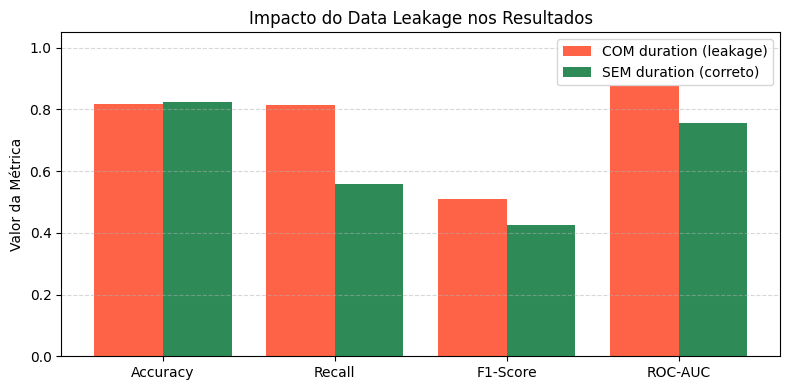

In [ ]:
# Modelo COM duration, "trapaceiro"

df_leakage = df.copy()
df_leakage['y'] = df_leakage['y'].map({'yes': 1, 'no': 0})
for col in df_leakage.select_dtypes(include='object').columns:
    df_leakage[col] = LabelEncoder().fit_transform(df_leakage[col])

X_leak = df_leakage.drop(columns=['y'])
y_leak = df_leakage['y']

X_train_l, X_test_l, y_train_l, y_test_l = train_test_split(
    X_leak, y_leak, test_size=0.2, random_state=42, stratify=y_leak
)

modelo_leak = DecisionTreeClassifier(
    max_depth=6, min_samples_leaf=20,
    class_weight='balanced', random_state=42
)
modelo_leak.fit(X_train_l, y_train_l)
y_pred_l = modelo_leak.predict(X_test_l)
y_prob_l = modelo_leak.predict_proba(X_test_l)[:, 1]

print("=== COM duration (data leakage) ===")
print(f"Accuracy:  {accuracy_score(y_test_l, y_pred_l):.4f}")
print(f"Recall:    {recall_score(y_test_l, y_pred_l):.4f}")
print(f"F1-Score:  {f1_score(y_test_l, y_pred_l):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test_l, y_prob_l):.4f}")

print("\n=== SEM duration (correto) ===")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_otim):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_otim):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_otim):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_prob_otim):.4f}")

#Gráfico
categorias = ['Accuracy', 'Recall', 'F1-Score', 'ROC-AUC']
vals_leak = [
    accuracy_score(y_test_l, y_pred_l),
    recall_score(y_test_l, y_pred_l),
    f1_score(y_test_l, y_pred_l),
    roc_auc_score(y_test_l, y_prob_l)
]
vals_correto = [
    accuracy_score(y_test, y_pred_otim),
    recall_score(y_test, y_pred_otim),
    f1_score(y_test, y_pred_otim),
    roc_auc_score(y_test, y_prob_otim)
]

x = range(len(categorias))
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar([i - 0.2 for i in x], vals_leak, 0.4,
       label='COM duration (leakage)', color='tomato')
ax.bar([i + 0.2 for i in x], vals_correto, 0.4,
       label='SEM duration (correto)', color='seagreen')
ax.set_xticks(list(x))
ax.set_xticklabels(categorias)
ax.set_ylim(0, 1.05)
ax.set_title('Impacto do Data Leakage nos Resultados')
ax.set_ylabel('Valor da Métrica')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


Com a coluna duration, o ROC-AUC sobe de 0,74 para 0,87 —
parece muito melhor, mas é mentira. Na prática o banco não teria
essa informação na hora de decidir quem ligar.

## 6. Deployment

- O probelma do banco era identificar quem era mais provavel de dizer sim antes de realizar as ligações para economizar esforços.

- Foi analisado 4 modelos preditivos (e justifiquei a remoção de uma das colunas) para identificar o com maior precisão nessa advinhação.

- Sendo assim o melhor modelo apresenta ser o modelo **Random Forest**, apresentando o maior F1-Score e ROC-AUC entre os testados.

- Em geral, nenhum dos modelos é proximo do perfeito, mas qualquer um dos otimizados já permitiria ao banco reduzir significativamente o volume de ligações desnecessárias, direcionando os esforços para os clientes com maior chance de conversão.

- O modelo pode evoluir com técnicas mais avançadas (como SMOTE ou XGBoost), porém com aumento de complexidade e custo de processamento. Além disso, atributos ainda não mapeados no dataset podem ter relevância preditiva relevante e não foram considerados nesta análise.

##Conclusão Executiva

Em uma base de 45 mil clientes onde só 11,7% aceitariam a oferta, ligar pra todo mundo é caro e ineficiente. Com o modelo Random Forest, o banco consegue priorizar quem tem mais chance de dizer sim, reduzindo o volume de ligações desnecessárias.
O modelo não é perfeito, mas já resolve o problema principal: parar de tratar todo mundo igual. Mesmo errando em alguns casos, ele já permite que a equipe de marketing trabalhe de forma mais inteligente, ligando menos e convertendo mais.